<a href="https://colab.research.google.com/github/MohamedKhalidmk/DeepLearning/blob/main/Facial_Emotions_Rec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, zipfile, shutil
from google.colab import files

# ── Option A: Upload a zip file from your computer ──────────────────────────
# The FER-2013 dataset from Kaggle is typically downloaded as 'archive.zip'
# It contains train/ and test/ folders with subfolders per emotion class.
print("Please upload your FER-2013 zip file (e.g. archive.zip)...")
uploaded = files.upload()   # click 'Choose Files' and select your zip

zip_name = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {zip_name}  ({os.path.getsize(zip_name) / 1e6:.1f} MB)")

Please upload your FER-2013 zip file (e.g. archive.zip)...


Saving archive.zip to archive.zip

✅ Uploaded: archive.zip  (63.3 MB)


In [ ]:
# ── Extract the zip ─────────────────────────────────────────────────────────
EXTRACT_DIR = '/content/fer2013'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print(f"✅ Extracted to {EXTRACT_DIR}")

# ── Auto-detect the train/ and test/ directories ────────────────────────────
# Handles both flat layout (fer2013/train/) and nested (fer2013/fer2013/train/)
def find_split_dir(base, name):
    """Search up to 2 levels deep for a folder named `name`."""
    for root, dirs, _ in os.walk(base):
        if name in dirs:
            return os.path.join(root, name)
    return None

TRAIN_DIR_FOUND = find_split_dir(EXTRACT_DIR, 'train')
TEST_DIR_FOUND  = find_split_dir(EXTRACT_DIR, 'test')

assert TRAIN_DIR_FOUND, "❌ Could not find 'train' folder inside the zip!"
assert TEST_DIR_FOUND,  "❌ Could not find 'test' folder inside the zip!"

print(f"  train/ → {TRAIN_DIR_FOUND}")
print(f"  test/  → {TEST_DIR_FOUND}")

# ── Inspect structure ────────────────────────────────────────────────────────
print("\nDataset structure:")
for split, path in [('train', TRAIN_DIR_FOUND), ('test', TEST_DIR_FOUND)]:
    emotions = sorted(os.listdir(path))
    counts   = {e: len(os.listdir(os.path.join(path, e))) for e in emotions}
    total    = sum(counts.values())
    print(f"  {split}/  ({total:,} images)")
    for e, c in counts.items():
        print(f"    {e:12s}: {c:,}")

✅ Extracted to /content/fer2013
  train/ → /content/fer2013/train
  test/  → /content/fer2013/test

Dataset structure:
  train/  (28,709 images)
    angry       : 3,995
    disgust     : 436
    fear        : 4,097
    happy       : 7,215
    neutral     : 4,965
    sad         : 4,830
    surprise    : 3,171
  test/  (7,178 images)
    angry       : 958
    disgust     : 111
    fear        : 1,024
    happy       : 1,774
    neutral     : 1,233
    sad         : 1,247
    surprise    : 831


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
import random
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── Global Config ───────────────────────────────────────────────────────────
IMG_SIZE    = 48          # FER-2013 native resolution
BATCH_SIZE  = 64
EPOCHS      = 60
NUM_CLASSES = 7
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Paths — adjust if your extraction path differs

# Paths resolved after upload (set in Step 0)
BASE_DIR  = '/content/fer2013'
TRAIN_DIR = TRAIN_DIR_FOUND   # resolved by the extractor cell above
TEST_DIR  = TEST_DIR_FOUND

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Samples per class:
          Train  Test
angry      3995   958
disgust     436   111
fear       4097  1024
happy      7215  1774
neutral    4965  1233
sad        4830  1247
surprise   3171   831

Total Train: 28,709
Total Test : 7,178


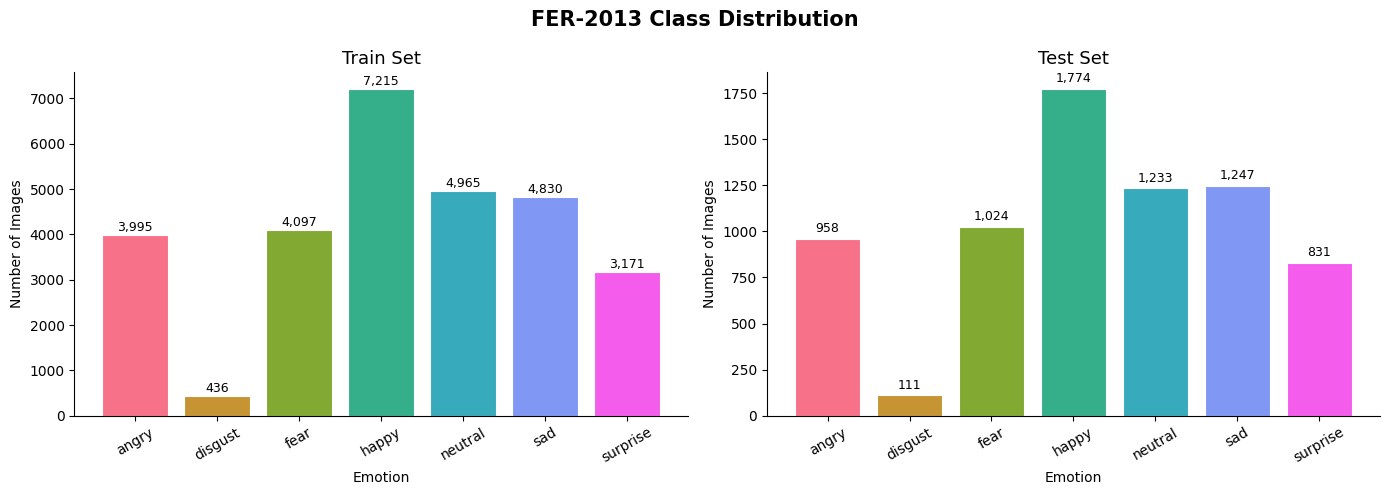

In [ ]:
# Count samples per class
def count_samples(directory):
    counts = {}
    for emotion in sorted(os.listdir(directory)):
        path = os.path.join(directory, emotion)
        if os.path.isdir(path):
            counts[emotion] = len(os.listdir(path))
    return counts

train_counts = count_samples(TRAIN_DIR)
test_counts  = count_samples(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
print("\nSamples per class:")
print(df_counts)
print(f"\nTotal Train: {df_counts['Train'].sum():,}")
print(f"Total Test : {df_counts['Test'].sum():,}")

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FER-2013 Class Distribution', fontsize=15, fontweight='bold')

colors = sns.color_palette('husl', NUM_CLASSES)

for ax, split in zip(axes, ['Train', 'Test']):
    bars = ax.bar(df_counts.index, df_counts[split], color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{split} Set', fontsize=13)
    ax.set_ylabel('Number of Images')
    ax.set_xlabel('Emotion')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, df_counts[split]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

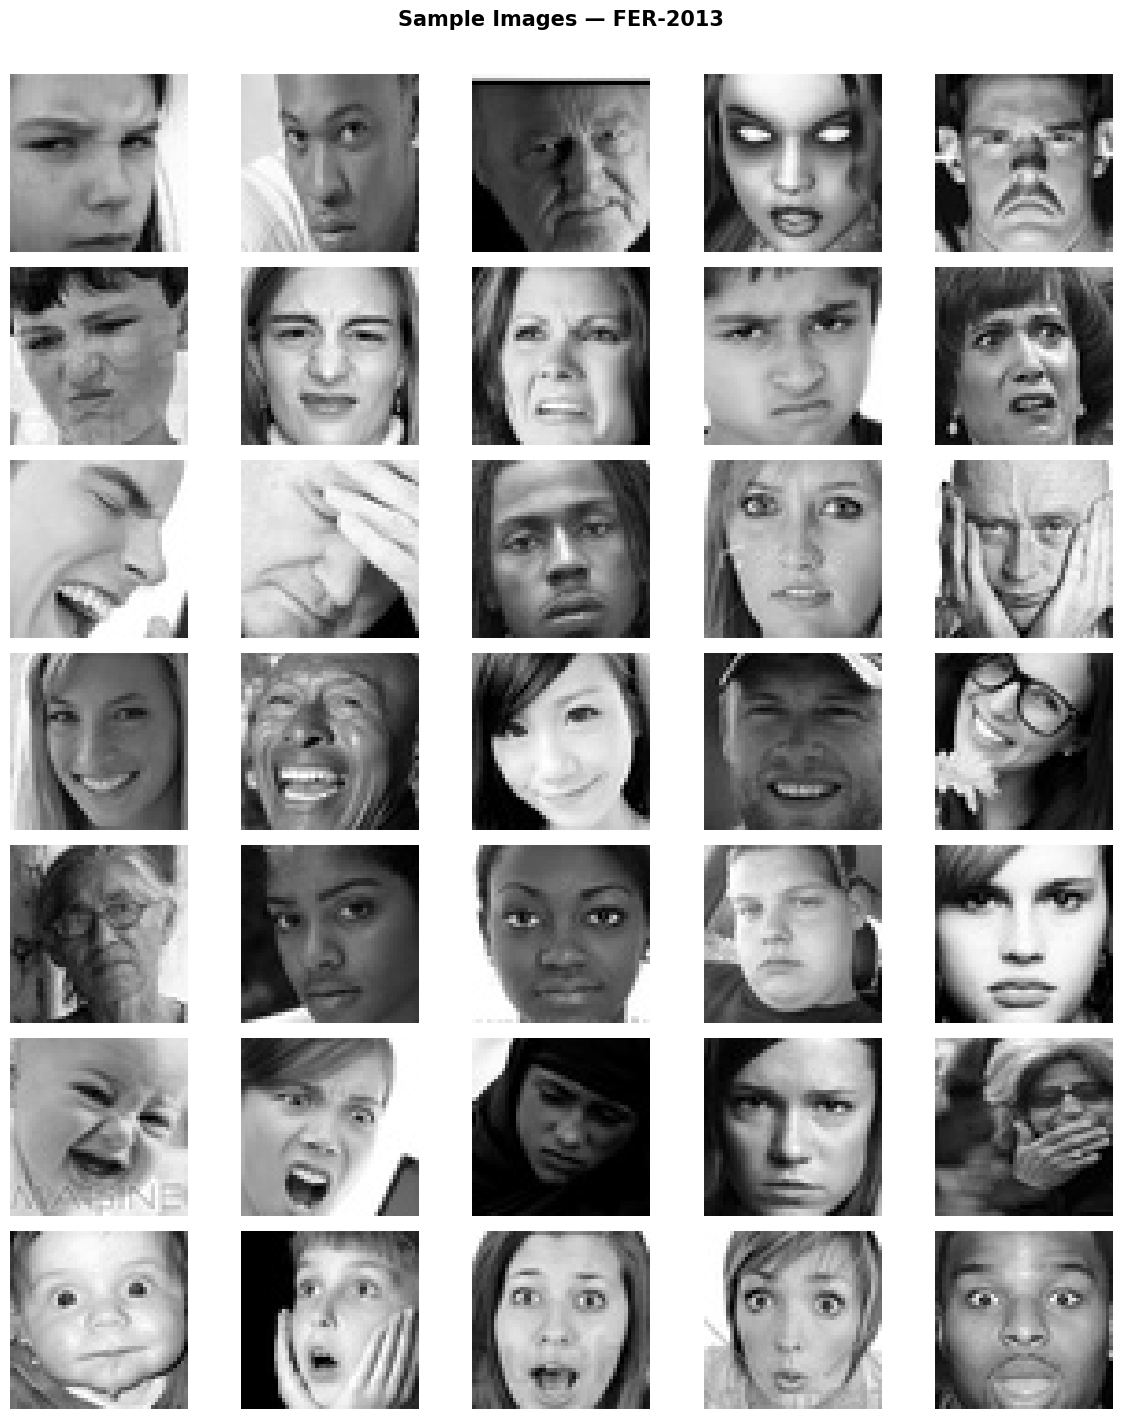

In [ ]:
# Visualise sample images from each class
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, NUM_CLASSES * 2))
fig.suptitle('Sample Images — FER-2013', fontsize=15, fontweight='bold', y=1.01)

for row, emotion in enumerate(sorted(train_counts.keys())):
    emotion_dir = os.path.join(TRAIN_DIR, emotion)
    samples = random.sample(os.listdir(emotion_dir), 5)
    for col, fname in enumerate(samples):
        img = cv2.imread(os.path.join(emotion_dir, fname), cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(emotion, fontsize=11, fontweight='bold',
                                       rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Training augmentation ────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255.0,   # Normalize 0-255 → 0-1
    rotation_range     = 20,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.1,
    fill_mode          = 'nearest',
    validation_split   = 0.15           # 15% of train → validation
)

# ── Validation / Test — only rescale ────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# ── Generators ──────────────────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size   = (IMG_SIZE, IMG_SIZE),
    color_mode    = 'grayscale',
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    subset        = 'training',
    seed          = SEED,
    shuffle       = True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size   = (IMG_SIZE, IMG_SIZE),
    color_mode    = 'grayscale',
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    subset        = 'validation',
    seed          = SEED,
    shuffle       = False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size   = (IMG_SIZE, IMG_SIZE),
    color_mode    = 'grayscale',
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    shuffle       = False
)

# Class index mapping
CLASS_MAP = {v: k for k, v in train_gen.class_indices.items()}
print("\nClass index mapping:", train_gen.class_indices)

Found 24406 images belonging to 7 classes.
Found 4303 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Class index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


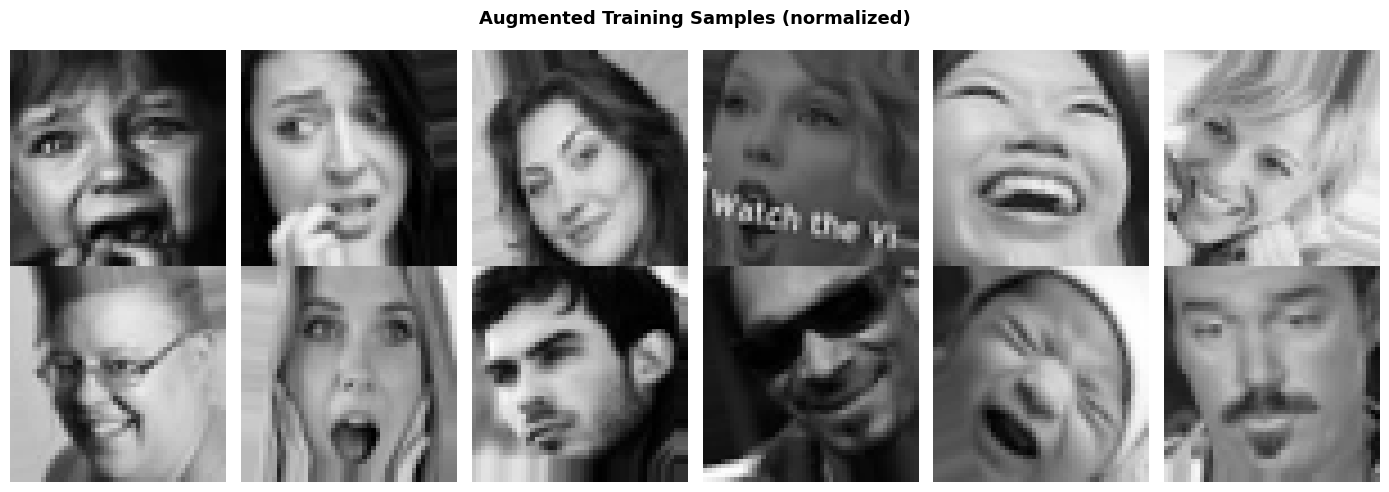

In [ ]:
# Preview augmented images
sample_imgs, _ = next(train_gen)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Augmented Training Samples (normalized)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def build_emotion_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Deep CNN for facial emotion recognition.
    - 4 convolutional blocks (≥3 required by spec)
    - Batch Normalization after every Conv layer
    - Dropout for regularisation
    - Global Average Pooling instead of Flatten
    """
    inputs = keras.Input(shape=input_shape, name='input_image')

    # ── Block 1 ─────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='relu1_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2 ─────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(0.30, name='drop2')(x)

    # ── Block 3 ─────────────────────────────────────────────────────────────
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='relu3_1')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='relu3_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = layers.Dropout(0.35, name='drop3')(x)

    # ── Block 4 ─────────────────────────────────────────────────────────────
    x = layers.Conv2D(512, (3, 3), padding='same', name='conv4_1')(x)
    x = layers.BatchNormalization(name='bn4_1')(x)
    x = layers.Activation('relu', name='relu4_1')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', name='conv4_2')(x)
    x = layers.BatchNormalization(name='bn4_2')(x)
    x = layers.Activation('relu', name='relu4_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool4')(x)
    x = layers.Dropout(0.40, name='drop4')(x)

    # ── Classifier head ─────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.5, name='drop_fc1')(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.4, name='drop_fc2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='EmotionCNN')
    return model


model = build_emotion_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES)
model.summary()

Model: "EmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 6, 6, 256)      │             

 Total params: 5,090,759 (19.42 MB)

 Trainable params: 5,085,383 (19.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [ ]:
# ── Compile ─────────────────────────────────────────────────────────────────
model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Quick sanity check — one forward pass
dummy = tf.random.normal((1, IMG_SIZE, IMG_SIZE, 1))
out   = model(dummy, training=False)
print(f"Output shape  : {out.shape}")      # (1, 7)
print(f"Sum of softmax: {out.numpy().sum():.4f}")   # should be ~1.0

Output shape  : (1, 7)
Sum of softmax: 1.0000


In [ ]:
# ── Class weights to handle imbalance ───────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

classes      = np.arange(NUM_CLASSES)
class_counts = np.array([train_counts[train_gen.class_indices.get(c, c)
                          if isinstance(c, str) else list(train_gen.class_indices.keys())[c]]
                         for c in range(NUM_CLASSES)])

# Simpler: derive directly from generator labels
raw_labels = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(raw_labels), y=raw_labels)
class_weights = dict(enumerate(cw))
print("Class weights:")
for idx, (emotion, w) in enumerate(zip(EMOTION_LABELS, cw)):
    print(f"  {emotion:10s}: {w:.4f}")

Class weights:
  Angry     : 1.0267
  Disgust   : 9.3978
  Fear      : 1.0010
  Happy     : 0.5685
  Sad       : 0.8260
  Surprise  : 0.8491
  Neutral   : 1.2932


In [ ]:
# ── Callbacks ───────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 12,
    restore_best_weights = True,
    verbose              = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor   = 'val_loss',
    factor    = 0.5,
    patience  = 5,
    min_lr    = 1e-6,
    verbose   = 1
)

checkpoint = ModelCheckpoint(
    filepath          = '/content/best_emotion_model.h5',
    monitor           = 'val_accuracy',
    save_best_only    = True,
    verbose           = 1
)

callbacks = [early_stop, reduce_lr, checkpoint]

# ── Train ────────────────────────────────────────────────────────────────────
history = model.fit(
    train_gen,
    epochs           = EPOCHS,
    validation_data  = val_gen,
    class_weight     = class_weights,
    callbacks        = callbacks,
    verbose          = 1
)

print("\n✅ Training complete!")

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.1488 - loss: 2.3081
Epoch 1: val_accuracy improved from None to 0.15059, saving model to /content/best_emotion_model.h5



Epoch 1: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step - accuracy: 0.1527 - loss: 2.2197 - val_accuracy: 0.1506 - val_loss: 1.9948 - learning_rate: 0.0010
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1658 - loss: 2.0835
Epoch 2: val_accuracy improved from 0.15059 to 0.15524, saving model to /content/best_emotion_model.h5



Epoch 2: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.1621 - loss: 2.0882 - val_accuracy: 0.1552 - val_loss: 2.1810 - learning_rate: 0.0010
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1735 - loss: 2.0246
Epoch 3: val_accuracy improved from 0.15524 to 0.20358, saving model to /content/best_emotion_model.h5



Epoch 3: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.1743 - loss: 2.0325 - val_accuracy: 0.2036 - val_loss: 1.9556 - learning_rate: 0.0010
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1946 - loss: 1.9814
Epoch 4: val_accuracy improved from 0.20358 to 0.21961, saving model to /content/best_emotion_model.h5



Epoch 4: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.1939 - loss: 1.9737 - val_accuracy: 0.2196 - val_loss: 1.9407 - learning_rate: 0.0010
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1762 - loss: 1.9624
Epoch 5: val_accuracy did not improve from 0.21961
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.1907 - loss: 1.9198 - val_accuracy: 0.1729 - val_loss: 2.0478 - learning_rate: 0.0010
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2414 - loss: 1.8621
Epoch 6: val_accuracy improved from 0.21961 to 0.31443, saving model to /content/best_emotion_model.h5


...


Epoch 36: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.5985 - loss: 1.0570 - val_accuracy: 0.6110 - val_loss: 1.0764 - learning_rate: 5.0000e-04
Epoch 37/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6018 - loss: 1.0497
Epoch 37: val_accuracy did not improve from 0.61097
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.6026 - loss: 1.0492 - val_accuracy: 0.6024 - val_loss: 1.0976 - learning_rate: 5.0000e-04
Epoch 38/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6058 - loss: 1.0346
Epoch 38: val_accuracy did not improve from 0.61097
382/382 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.6034 - loss: 1.0375 - val_accuracy: 0.6096 - val_loss: 1.0765 - learning_rate: 5.0000e-04
Epoch 39/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6080 - loss: 1.0385
Epoch 39: val_accuracy did not improve from 0.61097
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.6052 - loss: 1.


Epoch 43: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.6194 - loss: 0.9875 - val_accuracy: 0.6138 - val_loss: 1.0435 - learning_rate: 2.5000e-04
Epoch 44/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6102 - loss: 0.9890
Epoch 44: val_accuracy did not improve from 0.61376
382/382 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.6187 - loss: 0.9764 - val_accuracy: 0.6073 - val_loss: 1.0723 - learning_rate: 2.5000e-04
Epoch 45/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6237 - loss: 0.9777
Epoch 45: val_accuracy did not improve from 0.61376
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.6199 - loss: 0.9823 - val_accuracy: 0.5961 - val_loss: 1.1080 - learning_rate: 2.5000e-04
Epoch 46/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6180 - loss: 0.9594
Epoch 46: val_accuracy improved from 0.61376 to 0.62817, saving model to /content/best_emotion_model.h5



Epoch 46: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.6223 - loss: 0.9587 - val_accuracy: 0.6282 - val_loss: 1.0342 - learning_rate: 2.5000e-04
Epoch 47/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6260 - loss: 0.9447
Epoch 47: val_accuracy did not improve from 0.62817
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.6275 - loss: 0.9458 - val_accuracy: 0.6152 - val_loss: 1.0574 - learning_rate: 2.5000e-04
Epoch 48/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6248 - loss: 0.9549
Epoch 48: val_accuracy did not improve from 0.62817
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.6269 - loss: 0.9508 - val_accuracy: 0.6203 - val_loss: 1.0600 - learning_rate: 2.5000e-04
Epoch 49/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6389 - loss: 0.9307
Epoch 49: val_accuracy did not improve from 0.62817
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.6349 - loss: 0.


Epoch 55: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.6373 - loss: 0.9158 - val_accuracy: 0.6289 - val_loss: 1.0234 - learning_rate: 2.5000e-04
Epoch 56/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6379 - loss: 0.9167
Epoch 56: val_accuracy did not improve from 0.62886
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.6380 - loss: 0.9208 - val_accuracy: 0.6231 - val_loss: 1.0460 - learning_rate: 2.5000e-04
Epoch 57/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6361 - loss: 0.9240
Epoch 57: val_accuracy did not improve from 0.62886
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.6398 - loss: 0.9214 - val_accuracy: 0.6077 - val_loss: 1.0639 - learning_rate: 2.5000e-04
Epoch 58/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6356 - loss: 0.9068
Epoch 58: val_accuracy did not improve from 0.62886
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.6398 - loss: 0.


Epoch 59: finished saving model to /content/best_emotion_model.h5
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.6400 - loss: 0.9211 - val_accuracy: 0.6368 - val_loss: 1.0204 - learning_rate: 2.5000e-04
Epoch 60/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6424 - loss: 0.9151
Epoch 60: val_accuracy did not improve from 0.63677
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.6445 - loss: 0.9070 - val_accuracy: 0.6270 - val_loss: 1.0181 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 59.

✅ Training complete!


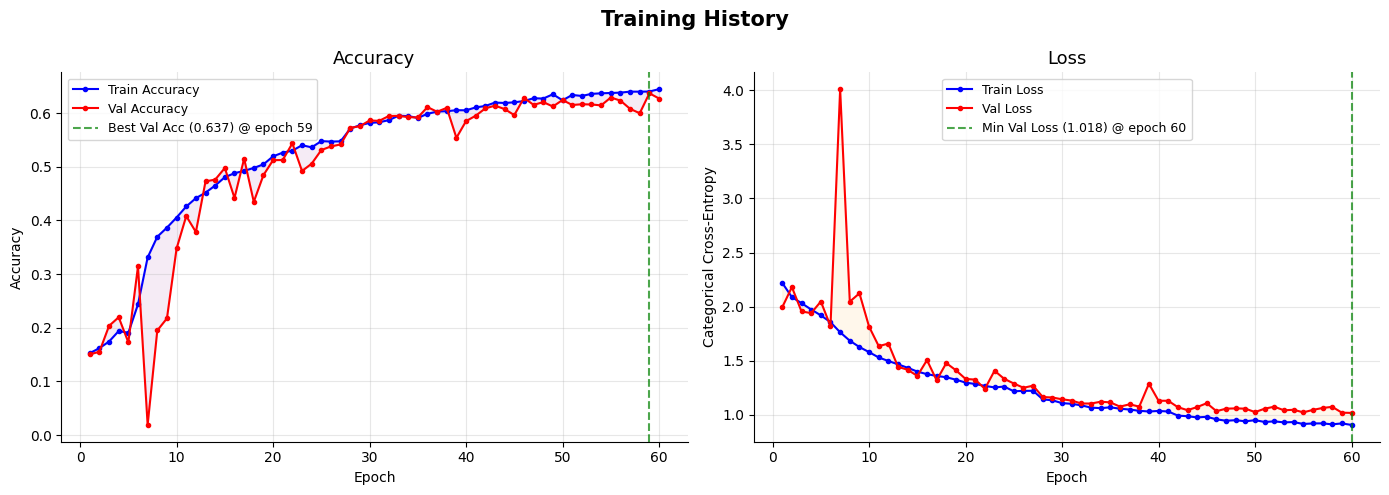

In [ ]:
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=15, fontweight='bold')

    # Accuracy
    ax1.plot(epochs, acc,     'b-o', markersize=3, label='Train Accuracy', linewidth=1.5)
    ax1.plot(epochs, val_acc, 'r-o', markersize=3, label='Val Accuracy',   linewidth=1.5)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.08, color='purple')
    best_ep = val_acc.index(max(val_acc)) + 1
    ax1.axvline(best_ep, color='green', linestyle='--', alpha=0.7,
                label=f'Best Val Acc ({max(val_acc):.3f}) @ epoch {best_ep}')
    ax1.set_title('Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    ax1.spines[['top','right']].set_visible(False)

    # Loss
    ax2.plot(epochs, loss,     'b-o', markersize=3, label='Train Loss', linewidth=1.5)
    ax2.plot(epochs, val_loss, 'r-o', markersize=3, label='Val Loss',   linewidth=1.5)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.08, color='orange')
    best_ep_loss = val_loss.index(min(val_loss)) + 1
    ax2.axvline(best_ep_loss, color='green', linestyle='--', alpha=0.7,
                label=f'Min Val Loss ({min(val_loss):.3f}) @ epoch {best_ep_loss}')
    ax2.set_title('Loss', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Categorical Cross-Entropy')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    ax2.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)

In [ ]:
# Load best checkpoint
model.load_weights('/content/best_emotion_model.h5')

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*40}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6514 - loss: 0.9714

  Test Loss     : 0.9714
  Test Accuracy : 0.6514  (65.14%)


In [ ]:
# Per-class classification report
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# Map indices to emotion names
index_to_emotion = {v: k for k, v in test_gen.class_indices.items()}
target_names     = [index_to_emotion[i] for i in range(NUM_CLASSES)]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.59      0.59      0.59       958
     disgust       0.47      0.71      0.57       111
        fear       0.54      0.33      0.41      1024
       happy       0.88      0.85      0.87      1774
     neutral       0.52      0.75      0.62      1233
         sad       0.56      0.47      0.51      1247
    surprise       0.74      0.82      0.78       831

    accuracy                           0.65      7178
   macro avg       0.62      0.64      0.62      7178
weighted avg       0.65      0.65      0.64      7178



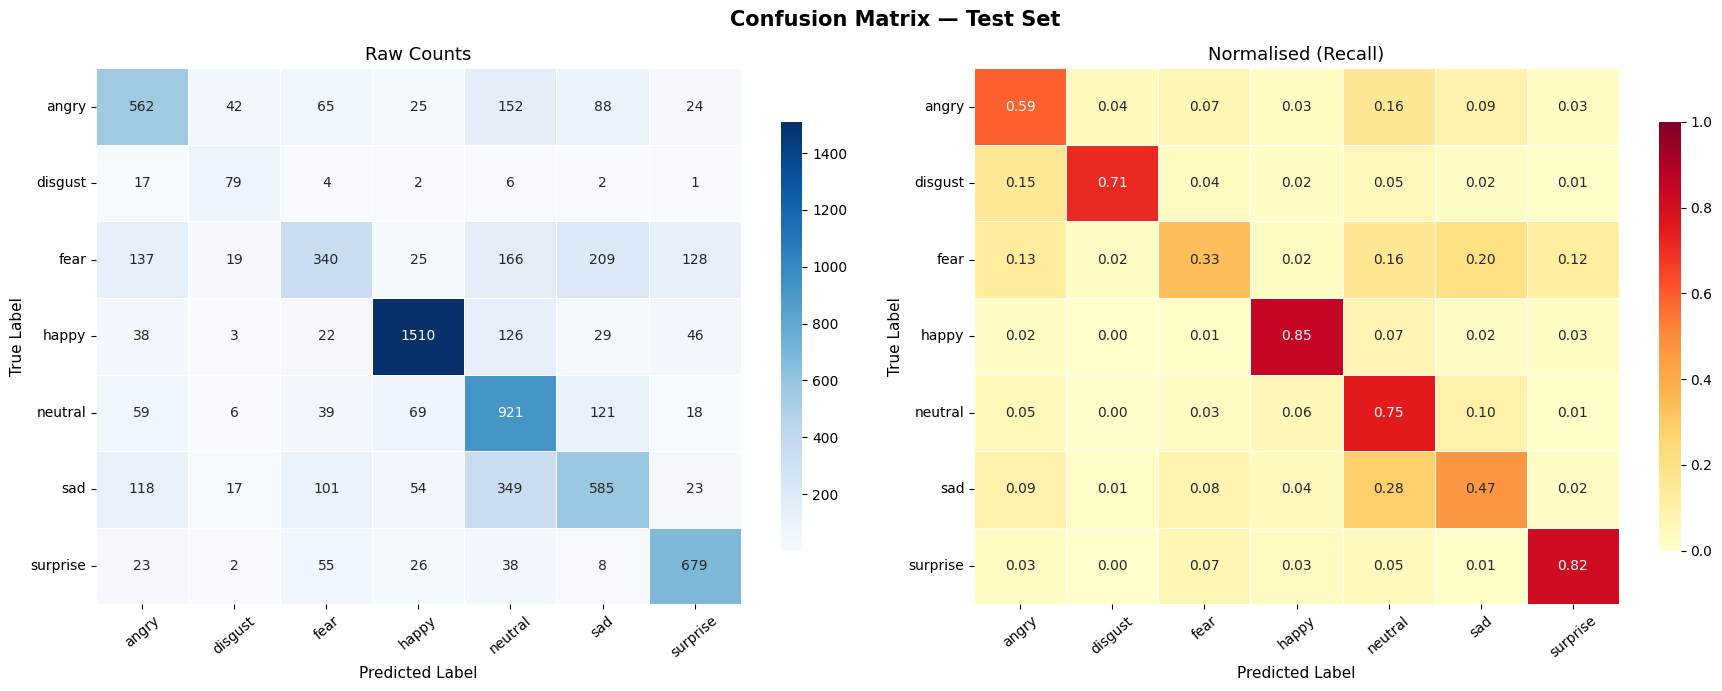


Top-5 Most Confused Emotion Pairs (excluding diagonal):
  1. True=sad        → Pred=neutral    :  349 samples (28.0%)
  2. True=fear       → Pred=sad        :  209 samples (20.4%)
  3. True=fear       → Pred=neutral    :  166 samples (16.2%)
  4. True=angry      → Pred=neutral    :  152 samples (15.9%)
  5. True=fear       → Pred=angry      :  137 samples (13.4%)


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white',
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=40)
axes[0].tick_params(axis='y', rotation=0)

# Normalised (recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Normalised (Recall)', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=40)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
print("\nTop-5 Most Confused Emotion Pairs (excluding diagonal):")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
flat_idx = np.argsort(cm_copy.ravel())[::-1][:5]
for rank, idx in enumerate(flat_idx, 1):
    true_idx  = idx // NUM_CLASSES
    pred_idx  = idx %  NUM_CLASSES
    count     = cm_copy[true_idx, pred_idx]
    pct       = cm_norm[true_idx, pred_idx] * 100
    print(f"  {rank}. True={target_names[true_idx]:10s} → Pred={target_names[pred_idx]:10s} : {count:4d} samples ({pct:.1f}%)")

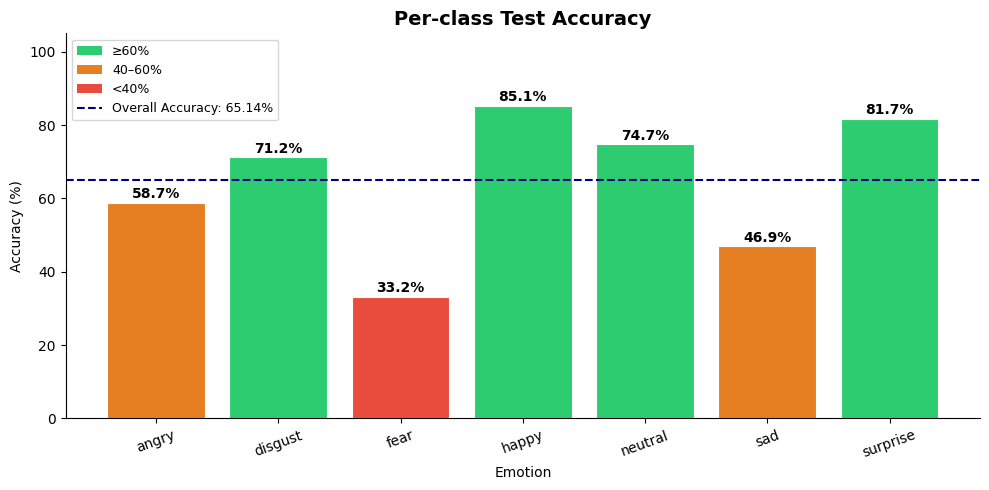

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if a >= 0.6 else '#e67e22' if a >= 0.4 else '#e74c3c'
          for a in per_class_acc]
bars = ax.bar(target_names, per_class_acc * 100, color=colors,
              edgecolor='white', linewidth=0.8)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(test_acc * 100, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Accuracy: {test_acc*100:.2f}%')
ax.set_ylim(0, 105)
ax.set_title('Per-class Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Emotion')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', rotation=20)

# Legend for colours
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='≥60%'),
              Patch(facecolor='#e67e22', label='40–60%'),
              Patch(facecolor='#e74c3c', label='<40%')]
ax.legend(handles=legend_els + [ax.lines[0]], fontsize=9)

plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

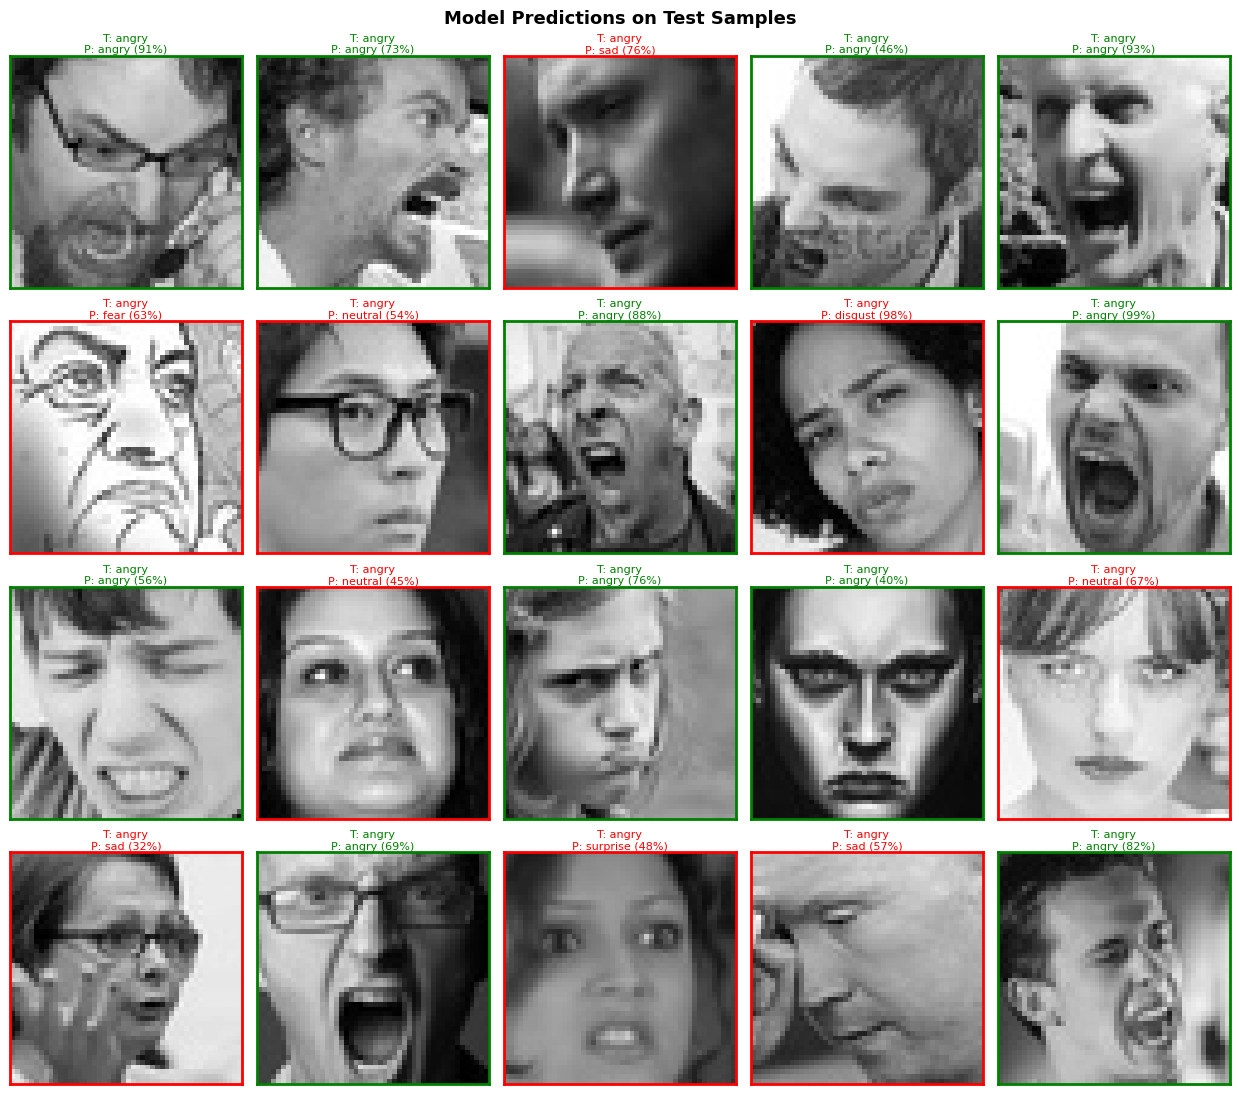

In [ ]:
def predict_and_display(generator, model, n=20, cols=5):
    generator.reset()
    imgs, labels = next(generator)
    imgs   = imgs[:n]
    labels = labels[:n]

    preds = model.predict(imgs, verbose=0)
    rows  = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    fig.suptitle('Model Predictions on Test Samples', fontsize=13, fontweight='bold')

    idx_to_name = {v: k for k, v in generator.class_indices.items()}

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(imgs[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        true_lbl = idx_to_name[np.argmax(labels[i])]
        pred_lbl = idx_to_name[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        correct  = true_lbl == pred_lbl
        color    = 'green' if correct else 'red'
        ax.set_title(f'T: {true_lbl}\nP: {pred_lbl} ({conf:.0f}%)',
                     fontsize=8, color=color, pad=2)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig('/content/qualitative_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

predict_and_display(test_gen, model, n=20, cols=5)

In [ ]:
# Save full model in modern Keras format
model.save('/content/emotion_cnn_final.keras')

# Save training history as CSV
hist_df = pd.DataFrame(history.history)
hist_df.index.name = 'epoch'
hist_df.to_csv('/content/training_history.csv')
print(hist_df.tail())

# Summary card
print("\n" + "="*45)
print("         FINAL RESULTS SUMMARY")
print("="*45)
print(f"  Best Val Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"  Test Accuracy     : {test_acc:.4f}")
print(f"  Test Loss         : {test_loss:.4f}")
print(f"  Total Parameters  : {model.count_params():,}")
print("="*45)

       accuracy      loss  val_accuracy  val_loss  learning_rate
epoch                                                           
55     0.637958  0.920833      0.623054  1.045972        0.00025
56     0.639802  0.921429      0.607716  1.063896        0.00025
57     0.639761  0.912414      0.599582  1.074320        0.00025
58     0.640007  0.921060      0.636765  1.020409        0.00025
59     0.644473  0.907025      0.627004  1.018125        0.00025

         FINAL RESULTS SUMMARY
  Best Val Accuracy : 0.6368
  Test Accuracy     : 0.6514
  Test Loss         : 0.9714
  Total Parameters  : 5,090,759


In [ ]:
# Download all outputs to local machine
from google.colab import files
outputs = [
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/per_class_accuracy.png',
    '/content/qualitative_predictions.png',
    '/content/class_distribution.png',
    '/content/training_history.csv',
    '/content/emotion_cnn_final.keras',
]
for f in outputs:
    files.download(f)
print("✅ All files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded.


In [ ]:
from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL
import io

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def take_photo():
    js = Javascript('''
    async function takePhoto() {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = '📸 Capture Emotion';
        capture.style = 'padding:8px 16px;font-size:14px;margin:10px;cursor:pointer;';
        div.appendChild(capture);
        document.body.appendChild(div);
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.removeChild(div);
        const video = document.createElement('video');
        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    img    = PIL.Image.open(io.BytesIO(binary))
    return np.array(img)

def predict_from_frame(frame, model, face_cascade):
    gray   = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces  = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    output = frame.copy()

    for (x, y, w, h) in faces:
        roi       = gray[y:y+h, x:x+w]
        roi_resz  = cv2.resize(roi, (IMG_SIZE, IMG_SIZE)) / 255.0
        roi_input = roi_resz.reshape(1, IMG_SIZE, IMG_SIZE, 1)
        probs     = model.predict(roi_input, verbose=0)[0]
        idx_to_name = {v: k for k, v in test_gen.class_indices.items()}
        emotion   = idx_to_name[np.argmax(probs)]
        conf      = np.max(probs) * 100
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(output, f'{emotion} ({conf:.0f}%)',
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 0), 2)

    if len(faces) == 0:
        cv2.putText(output, 'No face detected', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 100, 0), 2)
    return output

# Run
frame  = take_photo()
result = predict_from_frame(frame, model, face_cascade)
pil_img = PIL.Image.fromarray(result)
pil_img.save('/content/webcam_result.jpg')
display(pil_img)

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied